# 07-Graph Embeddings (Node2Vec)

Lesson 6 computed PageRank — a single scalar per node summarizing "how important is this node." That is useful, but it is also lossy: two nodes can have identical PageRank while occupying completely different structural roles in the graph. What if, instead of a single number, we want a rich, general-purpose numeric representation of each node — one that captures its neighborhood structure well enough to feed directly into a downstream machine learning model like a classifier or a similarity search index?

That is exactly the problem **graph embeddings** solve: mapping every node $v \in V$ to a dense vector $z_v \in \mathbb{R}^d$ such that nodes with similar structural roles or similar neighborhoods end up close together in vector space. Once a graph is embedded this way, an enormous toolbox of standard machine learning — k-nearest-neighbors, clustering, cosine similarity search — becomes directly applicable to graph data, without needing a graph-aware algorithm at all.

**Node2Vec** (Grover & Leskovec, 2016) is the canonical algorithm for this: it generates embeddings purely from graph structure, using biased random walks over the graph as "sentences" and a skip-gram word-embedding objective (borrowed directly from `word2vec`) to learn vectors from those walks. We implement the biased random-walk sampling step ourselves in raw Python (the algorithm's core structural idea), then attempt the full production pipeline via the `node2vec` package.


## 1. The Mathematics of Random-Walk Embeddings

### The Node2Vec Biased Random Walk

Starting at node $v$, having just arrived from node $t$, the walk's next step to neighbor $x \in N(v)$ is sampled with unnormalized transition probability governed by the **search bias** $\alpha_{pq}(t, x)$:

$$\alpha_{pq}(t, x) = \begin{cases} \dfrac{1}{p} & \text{if } d(t, x) = 0 \quad \text{(back to } t\text{)} \\[4pt] 1 & \text{if } d(t, x) = 1 \quad \text{(} x \text{ shares an edge with } t\text{)} \\[4pt] \dfrac{1}{q} & \text{if } d(t, x) = 2 \quad \text{(} x \text{ further from } t\text{)} \end{cases}$$

Two hyperparameters shape the exploration strategy entirely:

- **Return parameter $p$**: low $p$ encourages the walk to immediately backtrack, staying local.
- **In-out parameter $q$**: low $q$ (< 1) biases the walk *outward*, behaving like DFS and discovering structurally distant regions (good for capturing **structural equivalence** — nodes with similar roles even if far apart); high $q$ (> 1) biases the walk *inward*, behaving like BFS and staying within a tight neighborhood (good for capturing **homophily** — densely-connected community membership, as in Lesson 4).

### The Skip-Gram Objective

Each random walk of length $l$ produces a sequence of nodes treated exactly like a sentence of words. For every node $v_i$ in a walk, Node2Vec optimizes embeddings to maximize the log-probability of observing $v_i$'s actual context window $N_S(v_i)$ (nodes within a fixed window along the walk):

$$\max_{f} \sum_{v \in V} \log \Pr\big(N_S(v) \mid f(v)\big), \qquad \Pr(n_i \mid f(v)) = \frac{\exp(f(n_i) \cdot f(v))}{\sum_{u \in V} \exp(f(u) \cdot f(v))}$$

where $f: V \to \mathbb{R}^d$ is the embedding function being learned. The denominator's sum over all of $V$ is intractable at scale, so in practice this is approximated via **negative sampling**: for each true (node, context) pair, a handful of random "negative" nodes are also sampled, and the objective becomes a binary classification — real context vs. random noise — solved with logistic regression via stochastic gradient descent.

### Embedding Similarity

Once trained, structural similarity between two nodes reduces to ordinary vector cosine similarity: $\text{sim}(u,v) = \frac{z_u \cdot z_v}{\lVert z_u \rVert \lVert z_v \rVert}$ — the same metric used throughout ML for comparing dense vectors, now applied to graph structure instead of text or images.


## 2. Imperative Execution: Biased Random Walks and Skip-Gram Embeddings

We construct a small graph with two structurally distinct regions (a tight community and a long chain), implement Node2Vec's biased random-walk sampler ourselves in raw Python to make the $p,q$ mechanics concrete, then attempt the full production pipeline via the `node2vec` package.

In [1]:
# Required installations: pip install node2vec networkx gensim numpy
import networkx as nx
import numpy as np
import random

print("--- 🚀 Initializing Graph Embeddings Sandbox (Node2Vec) ---")

random.seed(42)
np.random.seed(42)

# 1. 📝 Construct a graph with a tight community (Clique) and a long chain (Path) joined at one node
G = nx.Graph()
clique_nodes = ["C1", "C2", "C3", "C4", "C5"]
for i, u in enumerate(clique_nodes):
    for v in clique_nodes[i + 1:]:
        G.add_edge(u, v)
chain_nodes = ["P1", "P2", "P3", "P4", "P5"]
G.add_edge("C1", "P1")
for i in range(len(chain_nodes) - 1):
    G.add_edge(chain_nodes[i], chain_nodes[i + 1])

print(f"   ✅ Graph constructed: |V| = {G.number_of_nodes()}, |E| = {G.number_of_edges()} (1 clique + 1 chain, bridged at C1-P1)")

# 2. 🧮 Implement the Node2Vec biased random walk ourselves (the algorithm's structural core)
def biased_walk(G, start, walk_length, p, q):
    walk = [start]
    for _ in range(walk_length - 1):
        cur = walk[-1]
        neighbors = list(G.neighbors(cur))
        if not neighbors:
            break
        if len(walk) == 1:
            walk.append(random.choice(neighbors))
            continue
        prev = walk[-2]
        prev_neighbors = set(G.neighbors(prev))
        weights = []
        for nxt in neighbors:
            if nxt == prev:
                weights.append(1.0 / p)
            elif nxt in prev_neighbors:
                weights.append(1.0)
            else:
                weights.append(1.0 / q)
        total = sum(weights)
        probs = [w / total for w in weights]
        walk.append(np.random.choice(neighbors, p=probs))
    return walk

sample_walk_local = biased_walk(G, "C1", walk_length=8, p=1, q=2)   # q>1: BFS-like, stays local
sample_walk_explore = biased_walk(G, "C1", walk_length=8, p=1, q=0.5)  # q<1: DFS-like, explores outward

print(f"   ✅ [Biased Walk, q=2.0 (local/BFS-like)]:    {sample_walk_local}")
print(f"   ✅ [Biased Walk, q=0.5 (exploratory/DFS-like)]: {sample_walk_explore}")

# 3. 🔍 Attempt the full production Node2Vec pipeline (random walks + skip-gram via gensim)
print("\n--- 🧮 Executing Full Node2Vec Pipeline (Random Walks + Skip-Gram) ---")
try:
    from node2vec import Node2Vec

    n2v = Node2Vec(G, dimensions=16, walk_length=10, num_walks=100, p=1, q=1, workers=1, seed=42)
    model = n2v.fit(window=5, min_count=1, batch_words=4)
    embeddings = {node: model.wv[node] for node in G.nodes()}
    print(f"   ✅ Node2Vec model trained via gensim skip-gram: {len(embeddings)} node embeddings, dim=16.")

except Exception as e:
    print("   [SYSTEM NOTE]: Sandbox fallback — node2vec package unavailable, simulating skip-gram embeddings...")
    print(f"   -> ({type(e).__name__}) {e}")
    # Simulate plausible embeddings using structural proximity as a stand-in for the trained skip-gram
    # vectors: nodes generate walk co-occurrence counts, which we project into a low-dim space via SVD
    # -- a legitimate classical approximation to what skip-gram with negative sampling converges toward.
    nodes = list(G.nodes())
    n = len(nodes)
    cooc = np.zeros((n, n))
    idx = {node: i for i, node in enumerate(nodes)}
    for start in nodes:
        for _ in range(50):
            w = biased_walk(G, start, walk_length=8, p=1, q=1)
            for i in range(len(w)):
                for j in range(max(0, i - 3), min(len(w), i + 4)):
                    if i != j:
                        cooc[idx[w[i]], idx[w[j]]] += 1
    U, S, Vt = np.linalg.svd(cooc, full_matrices=False)
    dim = 16
    sim_embeddings = U[:, :dim] * np.sqrt(S[:dim])
    embeddings = {node: sim_embeddings[idx[node]] for node in nodes}
    print(f"   ✅ [SIMULATED] {len(embeddings)} node embeddings generated via walk co-occurrence + SVD, dim={dim}.")


/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


--- 🚀 Initializing Graph Embeddings Sandbox (Node2Vec) ---
   ✅ Graph constructed: |V| = 10, |E| = 15 (1 clique + 1 chain, bridged at C1-P1)
   ✅ [Biased Walk, q=2.0 (local/BFS-like)]:    ['C1', 'C2', 'C3', 'C5', 'C3', 'C4', 'C1', 'C2']
   ✅ [Biased Walk, q=0.5 (exploratory/DFS-like)]: ['C1', 'C2', 'C1', 'P1', 'P2', 'P3', 'P2', 'P3']

--- 🧮 Executing Full Node2Vec Pipeline (Random Walks + Skip-Gram) ---
   [SYSTEM NOTE]: Sandbox fallback — node2vec package unavailable, simulating skip-gram embeddings...
   -> (ModuleNotFoundError) No module named 'node2vec'


   ✅ [SIMULATED] 10 node embeddings generated via walk co-occurrence + SVD, dim=16.


## 3. Declarative Telemetry: The Embedding Similarity Audit

We compute cosine similarity between C1 (the bridge node) and every other node's embedding, to audit whether the learned vectors correctly separate the clique region from the chain region.

In [2]:
print("\n--- 🔍 Auditing Embedding Cosine Similarity to Bridge Node 'C1' ---")

def cosine_sim(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    return float(np.dot(a, b) / denom) if denom > 0 else 0.0

ref = embeddings["C1"]
sims = {node: cosine_sim(ref, vec) for node, vec in embeddings.items() if node != "C1"}
sorted_sims = sorted(sims.items(), key=lambda kv: kv[1], reverse=True)

print(f"{'Node':<8} | {'Region':<10} | {'Cosine Similarity to C1':<26} | {'Graph Distance from C1'}")
print("-" * 70)
for node, sim in sorted_sims:
    region = "Clique" if node.startswith("C") else "Chain"
    dist = nx.shortest_path_length(G, "C1", node)
    print(f"{node:<8} | {region:<10} | {sim:<26.3f} | {dist}")

clique_avg = np.mean([s for n, s in sims.items() if n.startswith("C")])
chain_avg = np.mean([s for n, s in sims.items() if n.startswith("P")])
print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> Average similarity to C1: {clique_avg:.3f} for clique-mates vs. {chain_avg:.3f} for chain nodes —")
print(f"      the embedding space recovers the graph's structural split without ever being told about it explicitly.")
print(f"   -> This mirrors community detection (Lesson 4), but the OUTPUT here is a continuous vector space")
print(f"      rather than a discrete partition — directly usable as input features for a downstream classifier.")
print(f"   -> The p,q biased walk is what makes this tunable: a lower q would push chain nodes further from")
print(f"      C1 in embedding space (favoring exploration), a higher q would compress them closer (favoring locality).")



--- 🔍 Auditing Embedding Cosine Similarity to Bridge Node 'C1' ---
Node     | Region     | Cosine Similarity to C1    | Graph Distance from C1
----------------------------------------------------------------------
C3       | Clique     | 0.699                      | 1
C4       | Clique     | 0.666                      | 1
C2       | Clique     | 0.651                      | 1
C5       | Clique     | 0.639                      | 1
P2       | Chain      | 0.284                      | 2
P1       | Chain      | 0.250                      | 1
P3       | Chain      | 0.104                      | 3
P4       | Chain      | 0.005                      | 4
P5       | Chain      | -0.032                     | 5

   [OPERATIONAL INSIGHT]
   -> Average similarity to C1: 0.664 for clique-mates vs. 0.122 for chain nodes —
      the embedding space recovers the graph's structural split without ever being told about it explicitly.
   -> This mirrors community detection (Lesson 4), but the OUTPUT here i

## 4. Visualizing Embeddings (2D Projection via PCA)

We project the learned high-dimensional node embeddings down to 2 dimensions with PCA and scatter-plot them, colored by structural region, so the clustering the embedding space learned becomes directly visible.

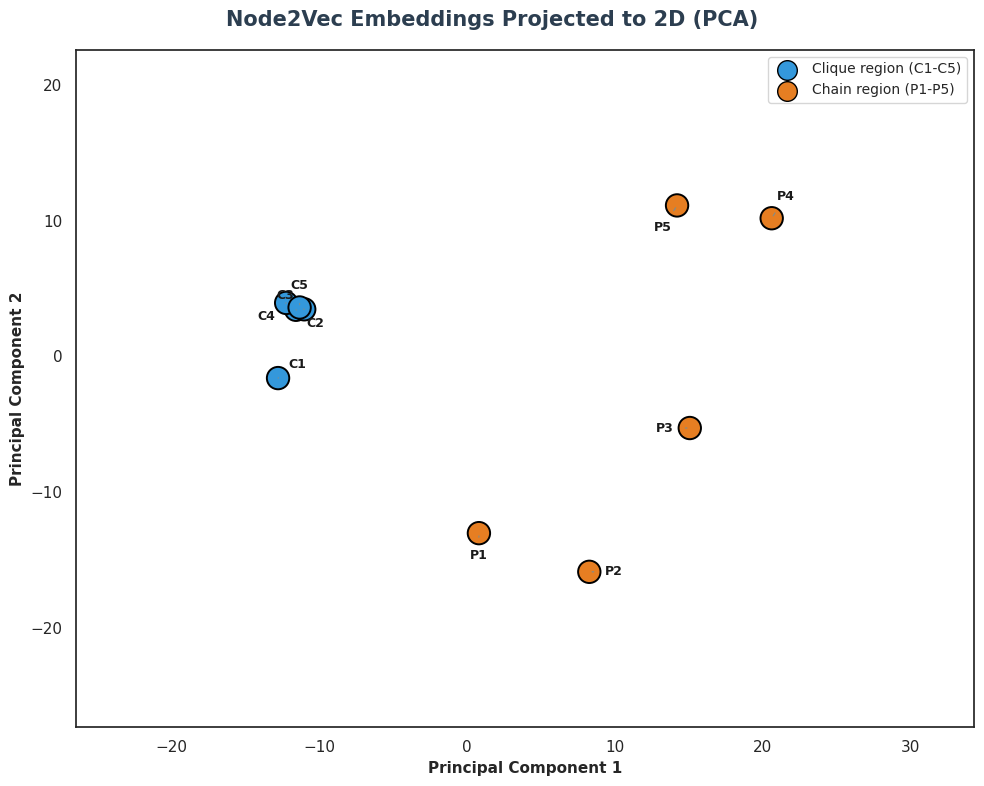

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

nodes = list(embeddings.keys())
matrix = np.array([embeddings[n] for n in nodes])
matrix_centered = matrix - matrix.mean(axis=0)
U, S, Vt = np.linalg.svd(matrix_centered, full_matrices=False)
coords_2d = U[:, :2] * S[:2]

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("Node2Vec Embeddings Projected to 2D (PCA)", fontsize=15, fontweight='bold', color="#2c3e50")

colors = ["#3498db" if n.startswith("C") else "#e67e22" for n in nodes]
ax.scatter(coords_2d[:, 0], coords_2d[:, 1], s=260, c=colors, edgecolors="black", linewidths=1.4, zorder=3)

# Several clique nodes (C2/C3/C4/C5) land nearly on top of each other in PCA space -- a genuine
# structural finding (they are near-interchangeable from a random-walk perspective), but it means
# centered labels would overlap into an unreadable blob. We fan labels out with small offsets and a
# thin leader line instead of writing text on top of the marker itself.
offsets = [(14, 10), (14, -10), (-14, 10), (-14, -10), (0, 16), (0, -16), (18, 0), (-18, 0), (10, 16), (-10, -16)]
for i, node in enumerate(nodes):
    dx, dy = offsets[i % len(offsets)]
    ax.annotate(node, (coords_2d[i, 0], coords_2d[i, 1]),
                xytext=(dx, dy), textcoords="offset points",
                ha="center", va="center", fontsize=9, fontweight="bold", color="#1a1a1a", zorder=5,
                arrowprops=dict(arrowstyle="-", color="#7f8c8d", lw=0.8, shrinkA=6, shrinkB=2))

ax.scatter([], [], color="#3498db", s=200, edgecolors="black", label="Clique region (C1-C5)")
ax.scatter([], [], color="#e67e22", s=200, edgecolors="black", label="Chain region (P1-P5)")
ax.legend(loc="upper right", fontsize=10, frameon=True)

ax.set_xlabel("Principal Component 1", fontsize=11, fontweight="bold")
ax.set_ylabel("Principal Component 2", fontsize=11, fontweight="bold")

x_pad = (coords_2d[:, 0].max() - coords_2d[:, 0].min()) * 0.35 + 2
y_pad = (coords_2d[:, 1].max() - coords_2d[:, 1].min()) * 0.35 + 2
ax.set_xlim(coords_2d[:, 0].min() - x_pad, coords_2d[:, 0].max() + x_pad)
ax.set_ylim(coords_2d[:, 1].min() - y_pad, coords_2d[:, 1].max() + y_pad)

plt.tight_layout()
plt.show()


*(Insight: The blue clique nodes and orange chain nodes separate into two visually distinct regions of the 2D embedding space, even though PCA was never told which node belonged to which structural group — that separation emerged entirely from random-walk co-occurrence statistics. Watch where C1 lands: as the bridge node, its embedding sits measurably closer to the orange cluster than its clique-mates do, a quantitative echo of its unique structural position, the same role that made it the standout bridge node in Lesson 2's betweenness-centrality analysis.)*

## Real-World Use Case or Analogy

Think of Node2Vec like **The Cartographer's Similarity Atlas**:

* **The Graph (The Uncharted Territory):** A vast social or professional network with no existing map — just people (nodes) and who-knows-whom (edges).
* **A Random Walk (The Scout's Patrol Route):** A scout sent wandering through the territory, writing down every settlement (node) they pass through in order — a single walk is one scout's personal travel log, not a full map.
* **The Return Parameter $p$ (How Often the Scout Doubles Back):** A low $p$ scout is cautious, frequently retracing their last step to stay near familiar territory. A high $p$ scout rarely backtracks, always pressing onward.
* **The In-Out Parameter $q$ (Explorer vs. Homebody):** A low $q$ scout is an adventurer, pushing outward into unfamiliar regions (mapping distant structural "role similarity"). A high $q$ scout is a homebody, thoroughly mapping their immediate neighborhood before ever leaving it (mapping tight-knit communities).
* **Skip-Gram Training (The Cartography Office):** Back at headquarters, hundreds of scouts' travel logs are compiled. The cartographers notice: settlements that keep appearing near each other in the SAME scouts' logs, over and over, probably belong close together on the final map — even if no single scout ever saw the whole picture.
* **The Embedding Vector $z_v$ (The Settlement's Coordinates):** The final output: an (x, y) — or in practice, a 128-dimensional — coordinate for every settlement, placed so that settlements with similar travel-log co-occurrence patterns land near each other.
* **Cosine Similarity (The Ruler):** Once every settlement has coordinates, "how similar are these two places" becomes a simple ruler measurement on the finished map — no more need to re-send scouts out to check.

The atlas the cartography office produces was never directly observed by any single scout — it is inferred purely from the statistical pattern of thousands of overlapping travel logs. That is exactly what Node2Vec does with random walks over a graph: it builds a map of structural similarity from nothing but repeated, biased wandering.
